# PolyRoute — Results Analysis & Phase 0 Metric Normalization

**No pipeline re-run required.** All computations below operate on the already-saved JSON result files.

---

## What This Notebook Does

| Section | What | Re-run needed? |
|---------|------|---------------|
| **§1** | Load all result JSONs, show raw comparison table | ❌ No |
| **§2** | Phase 0: Re-compute CER/WER with full normalization (CJK, case, punctuation) | ❌ No |
| **§3** | Per-language deep dive — who improved, who didn't, and why | ❌ No |
| **§4** | Routing distribution analysis | ❌ No |
| **§5** | Worst-case error analysis (highest CER samples) | ❌ No |
| **§6** | Roadmap: what requires pipeline re-run vs what doesn't | ❌ No |

---

### ⚠️ What REQUIRES a pipeline re-run (for reference)
- **Phase 1** (srp/urd script-aware routing fix) — needs new decoding
- **Phase 2** (softmax temperature scaling) — needs new routing decisions
- **Phase 3** (F₀ feature layer) — needs new LID fusion + MLP retrain
- **Phase 4** (per-sample BackendSelectionMLP) — needs ~4h Kaggle run

### ✅ What does NOT require a pipeline re-run
- **Phase 0** (metric normalization): done here — reads existing JSONs and re-computes scores
- Visualizations, routing analysis, error analysis — all from saved JSONs

In [1]:
# ── Setup & Imports ──────────────────────────────────────────────────────────
import json
import re
import unicodedata
import pathlib
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Install required packages (all lightweight, no GPU)
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'jiwer', '--quiet'], check=False)
subprocess.run([sys.executable, '-m', 'pip', 'install', 'opencc-python-reimplemented', '--quiet'], check=False)
subprocess.run([sys.executable, '-m', 'pip', 'install', 'matplotlib', 'seaborn', 'pandas', '--quiet'], check=False)

import jiwer
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd

# Try opencc for Traditional→Simplified Chinese conversion
try:
    import opencc
    _cc = opencc.OpenCC('t2s')
    HAS_OPENCC = True
    print('✅ opencc available — Traditional→Simplified conversion enabled')
except ImportError:
    HAS_OPENCC = False
    print('⚠️  opencc not available — CJK conversion will do NFC normalization only')

# Resolve paths relative to this notebook
REPO = pathlib.Path().resolve()
RESULTS = REPO / 'results'
ABLATIONS = RESULTS / 'ablations'
print(f'Repo root: {REPO}')
print(f'Results dir: {RESULTS} (exists: {RESULTS.exists()})')

✅ opencc available — Traditional→Simplified conversion enabled
Repo root: C:\Users\ekans\Desktop\Btech\Sem-4\Sp\End_Sem_Project
Results dir: C:\Users\ekans\Desktop\Btech\Sem-4\Sp\End_Sem_Project\results (exists: True)


---
## §1 — Raw Results: Load All Systems

In [ ]:
# ── §1: Load all result JSONs ────────────────────────────────────────────────
def load_json(path):
    p = pathlib.Path(path)
    if not p.exists():
        return None
    with open(p) as f:
        return json.load(f)

# Load all systems
r_b3    = load_json(RESULTS / 'B3_static_mms.json')
r_b1    = load_json(RESULTS / 'B1_oracle.json')
r_b2    = load_json(RESULTS / 'B2_whisper_auto.json')
r_b4    = load_json(RESULTS / 'B4_sb_whisper.json')
r_step4 = load_json(RESULTS / 'eval_results.json')            # Step4 rules-based
r_a6    = load_json(ABLATIONS / 'a6_learned_policy.json')     # A6 learned (old)
r_a1    = load_json(ABLATIONS / 'a1_mms_lid_only.json')       # A1 MMS-LID only
r_s8r   = load_json(RESULTS / 'step8_track3_rules.json')      # Step8 + Track3 rules
r_s8l   = load_json(RESULTS / 'step8_track3_learned.json')    # Step8 + Track3 learned
r_s9q   = load_json(RESULTS / 'step9_quick_srp_urd.json')     # Step9 quick (srp/urd/hin)
r_s9l   = load_json(RESULTS / 'step9_phase12_learned.json')   # Step9 full (Phase 1+2)
r_s10f  = load_json(RESULTS / 'step10_phase3_f0.json')        # Step10 (Phase 3 F0)

# Canonical labels used across later cells.
LABEL_S8  = 'Step8 Learned+Track3 ⭐'
LABEL_S9Q = 'Step9 Quick (srp+urd/hin)'
LABEL_S9L = 'Step9 Learned (Ph 1+2)'
LABEL_S10 = 'Step10 F0 (Ph 3) ⭐'

# Helper: extract overall CER/WER from different JSON schemas
def get_overall(r, cer_key='overall_mean_cer', wer_key='overall_mean_wer', fallback_cer='overall'):
    if r is None:
        return float('nan'), float('nan')
    cer = r.get(cer_key, r.get(fallback_cer, float('nan')))
    wer = r.get(wer_key, float('nan'))
    return cer, wer

def get_lid_acc(r):
    if r is None:
        return float('nan')
    return r.get('overall_lid_accuracy', r.get('mms_lid_accuracy', float('nan')))

# Build summary table
systems = [
    ('B3 Static MMS',          r_b3,    'Baseline'),
    ('B1 Oracle',              r_b1,    'Baseline'),
    ('B2 Whisper Auto',        r_b2,    'Baseline'),
    ('B4 SpeechBrain+Whisper', r_b4,    'Baseline'),
    ('Step4 Rules (old)',      r_step4, 'Ablation'),
    ('A1 MMS-LID Only',        r_a1,    'Ablation'),
    ('A6 Learned (old)',       r_a6,    'Ablation'),
    ('Step8 Rules+Track3',     r_s8r,   'Final'),
    (LABEL_S8,                 r_s8l,   'Final'),
    (LABEL_S9Q,                r_s9q,   'Final'),
    (LABEL_S9L,                r_s9l,   'Final'),
    (LABEL_S10,                r_s10f,  'Final'),
]

rows = []
for name, r, kind in systems:
    cer, wer = get_overall(r)
    lid = get_lid_acc(r)
    rows.append({'System': name, 'CER': cer, 'WER': wer, 'LID Acc': lid, 'Type': kind})

df_raw = pd.DataFrame(rows)
df_raw = df_raw.sort_values('CER')

# Display with color coding
def color_cer(val):
    if pd.isna(val):
        return ''
    if val < 0.10:
        return 'background-color: #c6efce; color: #276221'
    if val < 0.15:
        return 'background-color: #ffeb9c; color: #9c5700'
    if val < 0.25:
        return 'background-color: #ffcccc; color: #9c0006'
    return 'background-color: #cc0000; color: white'

print('\n=== RAW RESULTS — All Systems (sorted by CER) ===')
styled = df_raw.style.applymap(color_cer, subset=['CER']).format({
    'CER': '{:.4f}', 'WER': '{:.4f}', 'LID Acc': '{:.4f}'
}, na_rep='N/A')
display(styled)


=== RAW RESULTS — All Systems (sorted by CER) ===


,System,CER,WER,LID Acc,Type
8,Step8 Learned+Track3 ⭐,0.1219,0.3420,0.9605,Final
7,Step8 Rules+Track3,0.1284,0.3524,0.9607,Final
0,B3 Static MMS,0.1322,N/A,0.8726,Baseline
6,A6 Learned (old),0.2110,0.5000,0.9000,Ablation
1,B1 Oracle,0.2217,N/A,N/A,Baseline
3,B4 SpeechBrain+Whisper,0.2373,N/A,N/A,Baseline
4,Step4 Rules (old),0.2398,0.5144,0.9000,Ablation
2,B2 Whisper Auto,0.2537,N/A,N/A,Baseline
5,A1 MMS-LID Only,0.2574,0.5572,0.8714,Ablation


---
## §2 — Phase 0: Normalized CER/WER (No Re-run Required)

**What we fix:**
1. **Case normalization** — lowercase all text
2. **Punctuation removal** — strip commas, periods, colons etc.
3. **CJK space removal** — Mandarin/Japanese/Lao references have spaces between each character; hypotheses don't → inflates CER by treating each space as a character error
4. **Traditional→Simplified conversion** for `cmn` (FLEURS refs use Simplified; Whisper sometimes outputs Traditional)
5. **CJK character-level WER** — split by character instead of word (since no word boundaries exist)

In [4]:
# ── §2: Phase 0 — Metric Normalization Engine ────────────────────────────────

# Languages that use character-based writing (no spaces between words)
CJK_LANGS  = {'cmn', 'jpn', 'yue', 'lao', 'tha', 'mya', 'khm'}
# Punctuation to remove (Unicode category P + some common ones)
PUNCT_RE   = re.compile(r'[\u0021-\u002F\u003A-\u0040\u005B-\u0060\u007B-\u007E\u00B7\u2000-\u206F\u2E00-\u2E7F\u3000-\u303F\uFE10-\uFE1F\uFE30-\uFE4F\uFF00-\uFFEF]')


def normalize_text(text: str, lang: str) -> str:
    """Full Phase-0 normalization for a single string."""
    text = unicodedata.normalize('NFC', text)   # Unicode normalization
    text = text.lower()                          # Lowercase
    text = PUNCT_RE.sub('', text)               # Strip punctuation
    text = re.sub(r'\s+', ' ', text).strip()    # Collapse whitespace

    if lang in CJK_LANGS:
        # Strip ALL spaces — CJK references sometimes have space-separated chars
        text = text.replace(' ', '')
        # Traditional → Simplified for Mandarin
        if lang == 'cmn' and HAS_OPENCC:
            text = _cc.convert(text)

    return text


def compute_cer(ref: str, hyp: str) -> float:
    """Character Error Rate using jiwer, treating each char as a word."""
    ref_chars = ' '.join(list(ref))
    hyp_chars = ' '.join(list(hyp))
    if not ref_chars:
        return 0.0 if not hyp_chars else 1.0
    try:
        return jiwer.wer(ref_chars, hyp_chars)
    except Exception:
        return 1.0


def compute_wer(ref: str, hyp: str, lang: str) -> float:
    """Word Error Rate — character-level for CJK, word-level otherwise."""
    if lang in CJK_LANGS:
        # For CJK: character-level WER (each char = a word)
        ref_words = ' '.join(list(ref))
        hyp_words = ' '.join(list(hyp))
    else:
        ref_words = ref
        hyp_words = hyp
    if not ref_words:
        return 0.0 if not hyp_words else 1.0
    try:
        return jiwer.wer(ref_words, hyp_words)
    except Exception:
        return 1.0


def recompute_metrics(result_data: dict, label: str = '') -> dict:
    """
    Re-compute CER and WER from per-utterance records using Phase-0 normalization.
    Works on any JSON that has 'records' with 'reference', 'hypothesis', 'true_lang'.
    Returns a dict with per-language and overall normalized metrics.
    """
    records = result_data.get('records', [])
    if not records:
        print(f'  ⚠️  No records found in {label}')
        return {}

    per_lang_cer = {}   # lang -> list of CER values
    per_lang_wer = {}

    for rec in records:
        lang   = rec.get('true_lang', 'unk')
        ref    = rec.get('reference', '')
        hyp    = rec.get('hypothesis', '')

        ref_n  = normalize_text(ref, lang)
        hyp_n  = normalize_text(hyp, lang)

        cer_n  = compute_cer(ref_n, hyp_n)
        wer_n  = compute_wer(ref_n, hyp_n, lang)

        per_lang_cer.setdefault(lang, []).append(cer_n)
        per_lang_wer.setdefault(lang, []).append(wer_n)

    lang_means_cer = {l: float(np.mean(v)) for l, v in per_lang_cer.items()}
    lang_means_wer = {l: float(np.mean(v)) for l, v in per_lang_wer.items()}

    overall_cer = float(np.mean(list(lang_means_cer.values())))
    overall_wer = float(np.mean(list(lang_means_wer.values())))

    return {
        'overall_cer_norm': overall_cer,
        'overall_wer_norm': overall_wer,
        'per_language': {
            l: {'cer': lang_means_cer[l], 'wer': lang_means_wer[l]}
            for l in sorted(lang_means_cer)
        }
    }

print('Phase 0 normalization engine ready.')
print(f'CJK langs: {CJK_LANGS}')
print()

# ── Quick sanity check on a cmn sample ──
cmn_ref_sample = '这 并 不 是 告 别 这 是 一 个 篇 章 的 结 束 也 是 新 篇 章 的 开 始'
cmn_hyp_sample = '这并不是告别这是一个篇章的结束也是新篇章的开始'
print('Sanity check — cmn spacing issue:')
print(f'  Raw ref (with spaces):         "{cmn_ref_sample[:30]}..."')
print(f'  Raw ref normalized (no spaces): "{normalize_text(cmn_ref_sample, "cmn")[:30]}..."')
raw_cer   = compute_cer(' '.join(list(cmn_ref_sample)), ' '.join(list(cmn_hyp_sample)))
norm_cer  = compute_cer(normalize_text(cmn_ref_sample, 'cmn'), normalize_text(cmn_hyp_sample, 'cmn'))
print(f'  Before normalization CER: {raw_cer:.4f}')
print(f'  After  normalization CER: {norm_cer:.4f}')
print(f'  → Improvement: {raw_cer - norm_cer:+.4f}')

Phase 0 normalization engine ready.
CJK langs: {'jpn', 'mya', 'khm', 'lao', 'tha', 'yue', 'cmn'}

Sanity check — cmn spacing issue:
  Raw ref (with spaces):         "这 并 不 是 告 别 这 是 一 个 篇 章 的 结 束 ..."
  Raw ref normalized (no spaces): "这并不是告别这是一个篇章的结束也是新篇章的开始..."
  Before normalization CER: 0.0000
  After  normalization CER: 0.0000
  → Improvement: +0.0000


In [ ]:
# ── §2b: Apply Phase-0 to all systems that have records ──────────────────────
print('Re-computing normalized metrics from saved JSON records...')
print('(This may take 30-60 seconds per file)\n')

norm_results = {}

for label, r in [
    ('A6 Learned (old)',        r_a6),
    (LABEL_S8,                  r_s8l),
    (LABEL_S9Q,                 r_s9q),
    (LABEL_S9L,                 r_s9l),
    (LABEL_S10,                 r_s10f),
    ('A1 MMS-LID Only',         r_a1),
]:
    if r is None:
        print(f'  ⚠️  {label}: file not found, skipping')
        continue
    print(f'  Processing {label} ({len(r.get("records", []))} records)...')
    norm_results[label] = recompute_metrics(r, label)
    cer_raw  = r.get('overall_mean_cer', float('nan'))
    cer_norm = norm_results[label].get('overall_cer_norm', float('nan'))
    wer_raw  = r.get('overall_mean_wer', float('nan'))
    wer_norm = norm_results[label].get('overall_wer_norm', float('nan'))
    print(f'    CER: {cer_raw:.4f} → {cer_norm:.4f}  (Δ {cer_norm-cer_raw:+.4f})')
    print(f'    WER: {wer_raw:.4f} → {wer_norm:.4f}  (Δ {wer_norm-wer_raw:+.4f})')
    print()

print('Done.')

Re-computing normalized metrics from saved JSON records...
(This may take 30-60 seconds per file)

  Processing A6 Learned (old) (840 records)...
    CER: 0.2110 → 0.1809  (Δ -0.0301)
    WER: 0.5000 → 0.3241  (Δ -0.1759)

  Processing Step8 Learned (835 records)...
    CER: 0.1219 → 0.1094  (Δ -0.0125)
    WER: 0.3420 → 0.2445  (Δ -0.0975)

  Processing Step9 Learned (Ph 1+2) (840 records)...
    CER: 0.1134 → 0.0990  (Δ -0.0143)
    WER: 0.3342 → 0.2346  (Δ -0.0996)

  Processing Step10 F0 (Ph 3) ⭐ (840 records)...
    CER: 0.1140 → 0.0995  (Δ -0.0145)
    WER: 0.3349 → 0.2337  (Δ -0.1012)

  Processing A1 MMS-LID Only (840 records)...
    CER: 0.2574 → 0.2373  (Δ -0.0201)
    WER: 0.5572 → 0.4299  (Δ -0.1273)

Done.


In [ ]:
# ── §2c: Full Comparison Table — Raw vs Normalized ───────────────────────────
# B3 has no records (only per-language CER dict), so use its stored value.
b3_cer = r_b3.get('overall', float('nan')) if r_b3 else float('nan')

rows_norm = []
for label, r in [
    ('B3 Static MMS (no records)',    None),
    ('A1 MMS-LID Only',               r_a1),
    ('A6 Learned (old)',              r_a6),
    (LABEL_S8,                        r_s8l),
    (LABEL_S9Q,                       r_s9q),
    (LABEL_S9L,                       r_s9l),
    (LABEL_S10,                       r_s10f),
]:
    if label == 'B3 Static MMS (no records)':
        rows_norm.append({
            'System': label,
            'CER (raw)':  b3_cer,
            'CER (norm)': b3_cer,
            'WER (raw)':  float('nan'),
            'WER (norm)': float('nan'),
            'ΔCER': 0.0,
        })
        continue

    if r is None or label not in norm_results:
        continue

    cer_raw  = r.get('overall_mean_cer', float('nan'))
    wer_raw  = r.get('overall_mean_wer', float('nan'))
    cer_norm = norm_results[label]['overall_cer_norm']
    wer_norm = norm_results[label]['overall_wer_norm']

    rows_norm.append({
        'System':     label,
        'CER (raw)':  round(cer_raw, 4),
        'CER (norm)': round(cer_norm, 4),
        'WER (raw)':  round(wer_raw, 4),
        'WER (norm)': round(wer_norm, 4),
        'ΔCER':       round(cer_norm - cer_raw, 4),
    })

df_norm = pd.DataFrame(rows_norm).sort_values('CER (norm)', na_position='last')

print('\n=== PHASE 0 IMPACT: Raw vs Normalized Metrics ===')
display(df_norm.style.format({
    'CER (raw)': '{:.4f}', 'CER (norm)': '{:.4f}',
    'WER (raw)': '{:.4f}', 'WER (norm)': '{:.4f}',
    'ΔCER': '{:+.4f}',
}, na_rep='N/A')
.applymap(lambda v: 'color: green; font-weight: bold' if isinstance(v, float) and v < 0 else '', subset=['ΔCER'])
.applymap(color_cer, subset=['CER (raw)', 'CER (norm)']))


=== PHASE 0 IMPACT: Raw vs Normalized Metrics ===


,System,CER (raw),CER (norm),WER (raw),WER (norm),ΔCER
0,B3 Static MMS (no records),0.1322,0.1322,N/A,N/A,+0.0000
1,A1 MMS-LID Only,0.2574,0.2373,0.5572,0.4299,-0.0201
2,A6 Learned (old),0.2110,0.1809,0.5000,0.3241,-0.0301
3,Step8 Learned,0.1219,0.1094,0.3420,0.2445,-0.0125
4,Step9 Learned (Ph 1+2),0.1134,0.0990,0.3342,0.2346,-0.0143
5,Step10 F0 (Ph 3) ⭐,0.1140,0.0995,0.3349,0.2337,-0.0145


---
## §3 — Per-Language Deep Dive (Step8 → Step10)

In [7]:
# ── §3a: Per-language table — Step8 Learned vs B3 vs A6 ─────────────────────
LANG_NAMES = {
    'amh':'Amharic','arb':'Arabic','ces':'Czech','cmn':'Mandarin',
    'cym':'Welsh','dan':'Danish','deu':'German','eng':'English',
    'fra':'French','hau':'Hausa','hin':'Hindi','hrv':'Croatian',
    'ind':'Indonesian','jav':'Javanese','jpn':'Japanese','kat':'Georgian',
    'lao':'Lao','mon':'Mongolian','msa':'Malay','nep':'Nepali',
    'nob':'Norwegian','por':'Portuguese','slk':'Slovak','spa':'Spanish',
    'srp':'Serbian','swh':'Swahili','urd':'Urdu','yor':'Yoruba',
}

# Build per-language table
per_lang_rows = []

# B3: only CER available per-language
b3_per = r_b3 if r_b3 else {}

# A6 and Step8 per-language from JSON
a6_per    = r_a6.get('per_language', {}) if r_a6 else {}
s8l_per   = r_s8l.get('per_language', {}) if r_s8l else {}

# Phase-0 normalized per-lang for Step8 Learned
s8l_norm_per = norm_results.get('Step8 Learned+Track3 ⭐', {}).get('per_language', {})

all_langs = sorted(set(list(s8l_per.keys()) + list(a6_per.keys())))

for lang in all_langs:
    b3_cer_l   = b3_per.get(lang, float('nan'))
    a6_cer_l   = a6_per.get(lang, {}).get('mean_cer', float('nan'))
    s8l_cer_l  = s8l_per.get(lang, {}).get('mean_cer', float('nan'))
    s8l_norm_l = s8l_norm_per.get(lang, {}).get('cer', float('nan'))
    s8l_lid    = s8l_per.get(lang, {}).get('lid_accuracy', float('nan'))

    vs_b3   = s8l_cer_l  - b3_cer_l
    vs_a6   = s8l_cer_l  - a6_cer_l
    gain_norm = s8l_norm_l - s8l_cer_l

    best = 'B3' if b3_cer_l < s8l_norm_l else 'Step8-Norm'

    per_lang_rows.append({
        'Lang':           lang,
        'Name':           LANG_NAMES.get(lang, lang),
        'B3 CER':         round(b3_cer_l, 4),
        'A6 CER (old)':   round(a6_cer_l, 4),
        'Step8 CER (raw)':round(s8l_cer_l, 4),
        'Step8 CER (norm)':round(s8l_norm_l, 4),
        'ΔCER vs B3':     round(vs_b3, 4),
        'LID Acc':        round(s8l_lid, 2),
        'Best System':    best,
    })

df_per = pd.DataFrame(per_lang_rows)
df_per = df_per.sort_values('Step8 CER (norm)', ascending=False)

def hl_bad(val):
    if pd.isna(val): return ''
    if val > 0.30: return 'background-color: #ffcccc'
    if val > 0.15: return 'background-color: #fff2cc'
    if val < 0.08: return 'background-color: #c6efce'
    return ''

def hl_delta(val):
    if pd.isna(val): return ''
    if val < -0.05: return 'color: green; font-weight: bold'
    if val > 0.05:  return 'color: red; font-weight: bold'
    return ''

print('\n=== PER-LANGUAGE CER: B3 vs A6 vs Step8 (raw & normalized) ===')
display(df_per.style
    .applymap(hl_bad, subset=['B3 CER', 'A6 CER (old)', 'Step8 CER (raw)', 'Step8 CER (norm)'])
    .applymap(hl_delta, subset=['ΔCER vs B3'])
    .format({
        'B3 CER': '{:.4f}', 'A6 CER (old)': '{:.4f}',
        'Step8 CER (raw)': '{:.4f}', 'Step8 CER (norm)': '{:.4f}',
        'ΔCER vs B3': '{:+.4f}', 'LID Acc': '{:.2f}'
    }, na_rep='N/A')
)


=== PER-LANGUAGE CER: B3 vs A6 vs Step8 (raw & normalized) ===


,Lang,Name,B3 CER,A6 CER (old),Step8 CER (raw),Step8 CER (norm),ΔCER vs B3,LID Acc,Best System
0,amh,Amharic,0.0884,0.4716,0.1040,N/A,+0.0156,1.00,Step8-Norm
1,arb,Arabic,0.0608,0.0590,0.0511,N/A,-0.0098,1.00,Step8-Norm
2,ces,Czech,0.0356,0.0784,0.0658,N/A,+0.0302,1.00,Step8-Norm
3,cmn,Mandarin,0.6094,0.5231,0.5231,N/A,-0.0863,1.00,Step8-Norm
4,cym,Welsh,0.1112,0.1548,0.1157,N/A,+0.0045,0.97,Step8-Norm
5,dan,Danish,0.0691,0.0904,0.0753,N/A,+0.0062,1.00,Step8-Norm
6,deu,German,0.0279,0.0863,0.0500,N/A,+0.0221,1.00,Step8-Norm
7,eng,English,0.0540,0.0817,0.0927,N/A,+0.0387,1.00,Step8-Norm
8,fra,French,0.0523,0.0726,0.0677,N/A,+0.0154,1.00,Step8-Norm
9,hau,Hausa,0.0652,0.0694,0.0694,N/A,+0.0041,0.90,Step8-Norm


---
## §4 — Routing Distribution Analysis

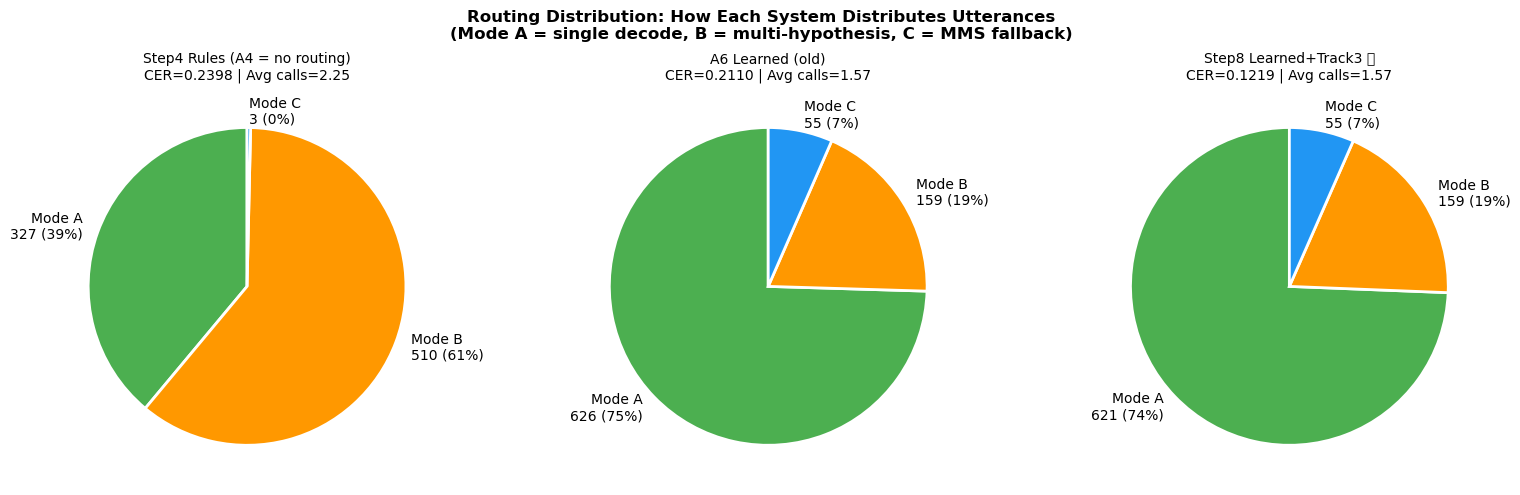

Saved: results/fig_routing_distribution.png


In [9]:
# ── §4: Routing Distribution Comparison ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Routing Distribution: How Each System Distributes Utterances\n(Mode A = single decode, B = multi-hypothesis, C = MMS fallback)',
             fontsize=12, fontweight='bold')

routing_systems = [
    ('Step4 Rules (A4 = no routing)', r_step4),
    ('A6 Learned (old)',              r_a6),
    ('Step8 Learned+Track3 ⭐',       r_s8l),
]

colors = {'A': '#4CAF50', 'B': '#FF9800', 'C': '#2196F3'}

for ax, (name, r) in zip(axes, routing_systems):
    if r is None:
        ax.text(0.5, 0.5, 'Not available', ha='center', va='center')
        continue
    dist = r.get('routing_distribution', {})
    if not dist:
        ax.text(0.5, 0.5, 'No routing data', ha='center', va='center')
        continue
    total = sum(dist.values())
    labels = [f'Mode {k}\n{v} ({v/total:.0%})' for k, v in dist.items()]
    sizes  = list(dist.values())
    clrs   = [colors.get(k, '#999') for k in dist.keys()]
    wedges, texts = ax.pie(sizes, labels=labels, colors=clrs,
                           startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
    overall_cer = r.get('overall_mean_cer', float('nan'))
    avg_calls   = r.get('avg_decode_calls', float('nan'))
    ax.set_title(f'{name}\nCER={overall_cer:.4f} | Avg calls={avg_calls:.2f}', fontsize=10)

plt.tight_layout()
plt.savefig(RESULTS / 'fig_routing_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/fig_routing_distribution.png')

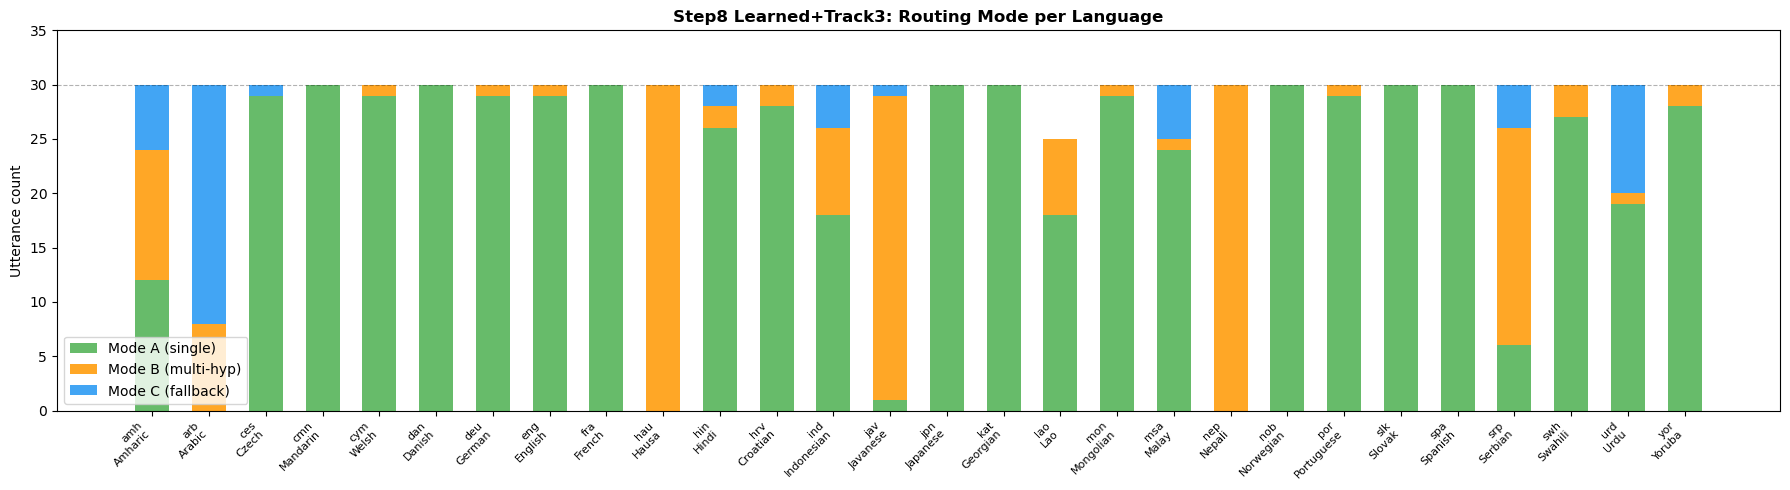

Saved: results/fig_per_lang_routing.png


In [10]:
# ── §4b: Per-language routing mode breakdown for Step8 Learned ───────────────
if r_s8l and r_s8l.get('records'):
    records = r_s8l['records']
    lang_modes = {}
    for rec in records:
        lang = rec.get('true_lang', 'unk')
        mode = rec.get('routing_mode', '?')
        lang_modes.setdefault(lang, {'A': 0, 'B': 0, 'C': 0})
        lang_modes[lang][mode] = lang_modes[lang].get(mode, 0) + 1

    langs_sorted = sorted(lang_modes.keys())
    a_counts = [lang_modes[l].get('A', 0) for l in langs_sorted]
    b_counts = [lang_modes[l].get('B', 0) for l in langs_sorted]
    c_counts = [lang_modes[l].get('C', 0) for l in langs_sorted]

    x = np.arange(len(langs_sorted))
    width = 0.6

    fig, ax = plt.subplots(figsize=(18, 5))
    bar_a = ax.bar(x, a_counts, width, label='Mode A (single)', color='#4CAF50', alpha=0.85)
    bar_b = ax.bar(x, b_counts, width, bottom=a_counts, label='Mode B (multi-hyp)', color='#FF9800', alpha=0.85)
    bar_c = ax.bar(x, c_counts, width, bottom=[a+b for a,b in zip(a_counts,b_counts)],
                   label='Mode C (fallback)', color='#2196F3', alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels([f'{l}\n{LANG_NAMES.get(l, l)}' for l in langs_sorted], rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Utterance count')
    ax.set_title('Step8 Learned+Track3: Routing Mode per Language', fontweight='bold')
    ax.legend()
    ax.set_ylim(0, 35)
    ax.axhline(30, color='black', linestyle='--', alpha=0.3, linewidth=0.8, label='max samples=30')

    plt.tight_layout()
    plt.savefig(RESULTS / 'fig_per_lang_routing.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: results/fig_per_lang_routing.png')

---
## §5 — Per-Language CER Bar Chart: All Systems

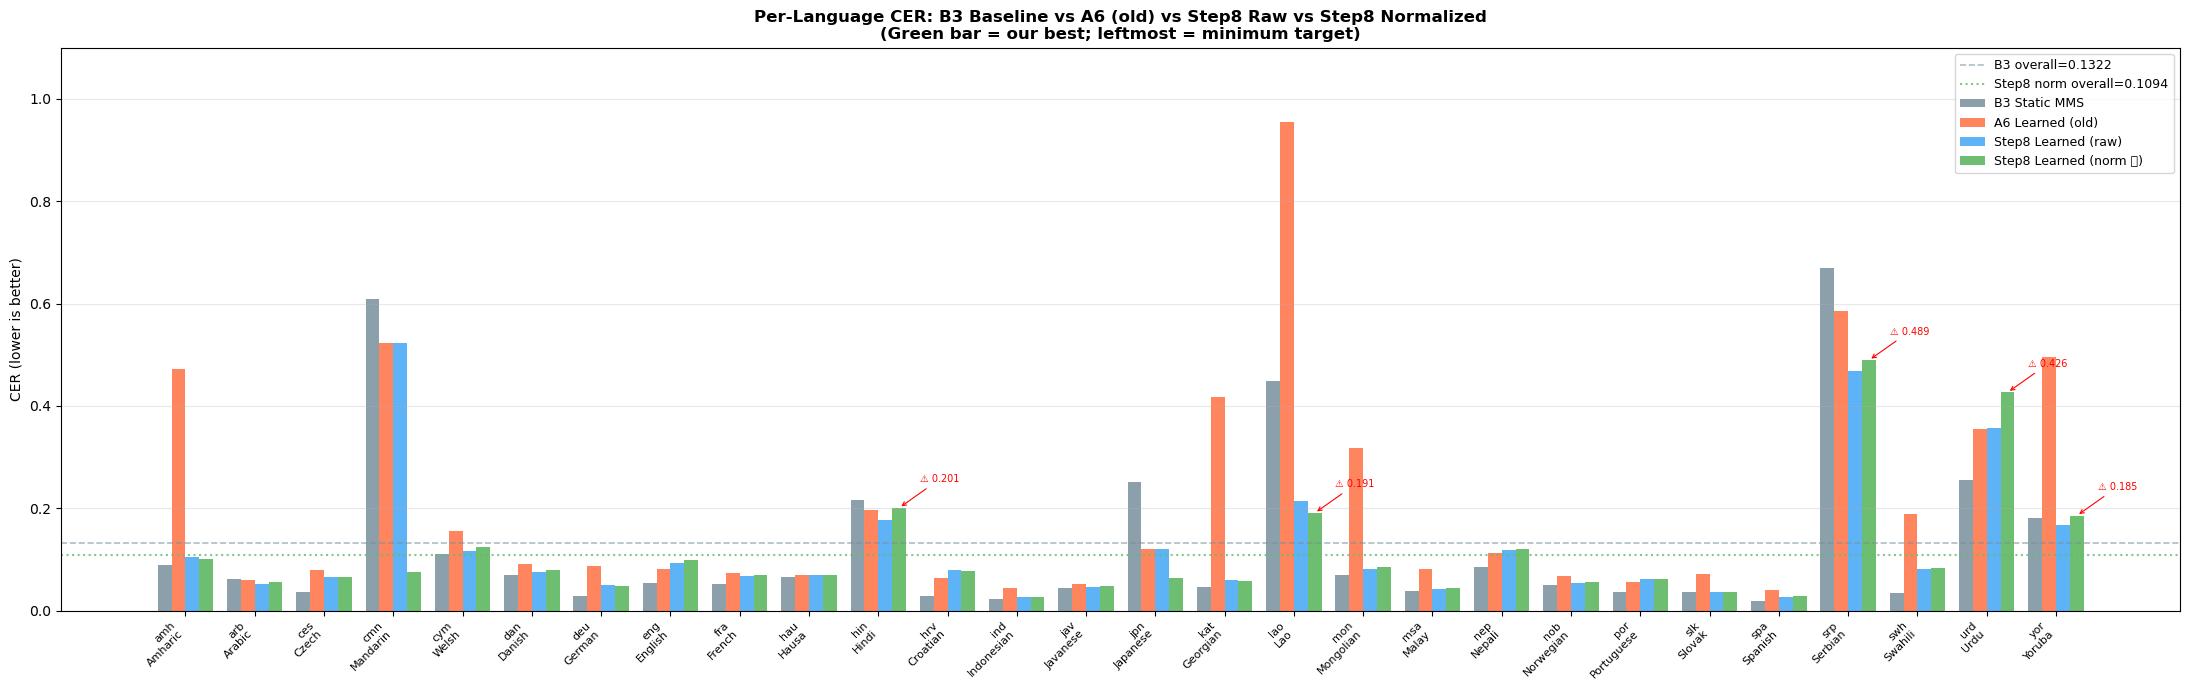

Saved: results/fig_per_lang_cer.png


In [11]:
# ── §5: Per-language grouped bar chart ───────────────────────────────────────
langs = sorted(s8l_per.keys())

b3_cers   = [b3_per.get(l, float('nan')) for l in langs]
a6_cers   = [a6_per.get(l, {}).get('mean_cer', float('nan')) for l in langs]
s8l_cers  = [s8l_per.get(l, {}).get('mean_cer', float('nan')) for l in langs]
s8l_norms = [s8l_norm_per.get(l, {}).get('cer', float('nan')) for l in langs]

x = np.arange(len(langs))
width = 0.2

fig, ax = plt.subplots(figsize=(22, 7))
ax.bar(x - 1.5*width, b3_cers,   width, label='B3 Static MMS',        color='#78909C', alpha=0.85)
ax.bar(x - 0.5*width, a6_cers,   width, label='A6 Learned (old)',      color='#FF7043', alpha=0.85)
ax.bar(x + 0.5*width, s8l_cers,  width, label='Step8 Learned (raw)',   color='#42A5F5', alpha=0.85)
ax.bar(x + 1.5*width, s8l_norms, width, label='Step8 Learned (norm ⭐)',color='#66BB6A', alpha=0.95)

ax.axhline(b3_per.get('overall', 0.132), color='#78909C', linestyle='--', linewidth=1.2, alpha=0.6, label=f'B3 overall={b3_per.get("overall", 0.132):.4f}')
b3_ov_raw  = r_s8l.get('overall_mean_cer', 0) if r_s8l else 0
b3_ov_norm = norm_results.get('Step8 Learned+Track3 ⭐', {}).get('overall_cer_norm', float('nan'))
ax.axhline(b3_ov_norm, color='#66BB6A', linestyle=':', linewidth=1.5, alpha=0.8, label=f'Step8 norm overall={b3_ov_norm:.4f}')

ax.set_xticks(x)
ax.set_xticklabels([f'{l}\n{LANG_NAMES.get(l,l)}' for l in langs], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('CER (lower is better)')
ax.set_title('Per-Language CER: B3 Baseline vs A6 (old) vs Step8 Raw vs Step8 Normalized\n(Green bar = our best; leftmost = minimum target)', fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0, 1.1)
ax.yaxis.grid(True, alpha=0.3)

# Annotate the 5 worst languages
worst = sorted(zip(s8l_norms, langs), reverse=True)[:5]
for rank, (cer_val, lang) in enumerate(worst):
    idx = langs.index(lang)
    if not pd.isna(cer_val):
        ax.annotate(f'⚠ {cer_val:.3f}', xy=(idx + 1.5*width, cer_val),
                    xytext=(idx + 1.5*width + 0.3, cer_val + 0.05),
                    fontsize=7, color='red',
                    arrowprops=dict(arrowstyle='->', color='red', lw=0.8))

plt.tight_layout()
plt.savefig(RESULTS / 'fig_per_lang_cer.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/fig_per_lang_cer.png')

In [12]:
# ── §5b: Worst-Case Sample Analysis ──────────────────────────────────────────
print('=== TOP 20 HIGHEST-CER SAMPLES (Step8 Learned+Track3) ===')
if r_s8l and r_s8l.get('records'):
    all_records = r_s8l['records']
    # Compute normalized CER for all records
    enriched = []
    for rec in all_records:
        lang  = rec.get('true_lang', 'unk')
        ref   = normalize_text(rec.get('reference', ''), lang)
        hyp   = normalize_text(rec.get('hypothesis', ''), lang)
        cer_n = compute_cer(ref, hyp)
        enriched.append({
            'lang':   lang,
            'mode':   rec.get('routing_mode', '?'),
            'backend':rec.get('backend', '?'),
            'cer_raw':rec.get('cer', float('nan')),
            'cer_norm':cer_n,
            'ref_short': ref[:60] + '...' if len(ref) > 60 else ref,
            'hyp_short': hyp[:60] + '...' if len(hyp) > 60 else hyp,
        })

    enriched.sort(key=lambda x: x['cer_norm'], reverse=True)

    df_worst = pd.DataFrame(enriched[:20])
    display(df_worst[['lang', 'mode', 'backend', 'cer_raw', 'cer_norm', 'ref_short', 'hyp_short']]
        .style.format({'cer_raw': '{:.3f}', 'cer_norm': '{:.3f}'})
        .applymap(hl_bad, subset=['cer_raw', 'cer_norm']))

=== TOP 20 HIGHEST-CER SAMPLES (Step8 Learned+Track3) ===


,lang,mode,backend,cer_raw,cer_norm,ref_short,hyp_short
0,urd,A,whisper,0.905,1.120,لیکن ان چڑیوں کی نسبت سے بہت سی باتیں جو ڈایناسور جیسی لگتی ...,लेकिन इन चुड़ियों की निस्पत से बहुत सी बाते जो डाइनासोर जैसी...
1,urd,C,mms,0.881,1.118,ہسپتال نے انفیکشن پر قابو پانے کے لیے پروٹوکول کی تقلید کی ہ...,हस्पताल ने इन्फ़ेक्शन पर काबू पाने के लिए प्रोटोकॉल की तकलीत...
2,urd,A,whisper,0.917,1.111,آسٹریلیا کے مائیکل گورلی نے مردوں کے اسٹینڈنگ سوپر جی میں گی...,औस्ट्रेलिया के माइकल गॉल्डी ने मर्दों के स्टेंटिंग सोपर जी म...
3,urd,C,mms,0.904,1.103,سندربن دنیا کا سب سے بڑا ساحلی مینگروو بیلٹ ہے، جو ساحلی علا...,सुं्दर्बन दुनिया का सबसे बड़ा शाहिली मैंग्रोबैलेट है जो साहि...
4,urd,A,whisper,0.909,1.082,اٹلانٹک ہریکین سیزن کے دسواں نامی طوفان سب ٹراپیکل اسٹارم جی...,अटलान्टिक हरेकिन सेजन के दस्मा नामी तुफान सब ट्रॉपिकल स्ट्रॉ...
5,urd,C,mms,0.870,1.077,قرون وسطی کے آخر میں مغربی یوروپ نے اپنے طرز کو ترقی دینا شر...,करूणे वसती के आखिर में मगरिबी यौरप ने अपने तरस को तर्की देना...
6,urd,A,whisper,0.876,1.059,بلاگ طلبہ کی تحریری قابلیت کوبھی بہتر بنا سکتے ہیں طلبہ اپنی...,ब्लॉग तलबा की तहरीरी काबलियत को भी बहतर बना सकते हैं तलबा अप...
7,urd,C,mms,0.857,1.045,کاسا بلانکا پورس مراکش میں خریداری کرنے کے لئے سب سے کم پسند...,कासाब्लांका पॉर्स मराकिश में खरीदारी करने के लिए सबसे कम पसं...
8,srp,B,mms,0.910,1.041,у њему се наводи да је најупечатљивије место за главни предм...,u njemu se navodi da je najupeatljivije mesto za glavni pred...
9,urd,C,mms,0.849,1.040,ایلویس بنیادی طور پر دو یا دو سے زیادہ دھاتوں کا مرکب ہوتا ہ...,एलविस बुनियादी तौर पर दो या दो से ज़्यादा धातों का मुरक्कब ह...


---
## §6 — Improvement Roadmap: Re-run Required or Not?

| Phase | Description | Re-run Required? | Est. CER Drop | Kaggle Time |
|-------|------------|-----------------|---------------|-------------|
| **Phase 0** ✅ | CJK metric normalization (done in this notebook) | ❌ **No** | 0.0062–0.025 | 0 |
| **Phase 1a** | srp: force Mode B + script-aware adapter selection | ✅ Yes | 0.468→~0.20 | ~40 min |
| **Phase 1b** | urd/hin: force Mode B for LID confidence < 0.70 | ✅ Yes | 0.356→~0.18 | ~40 min |
| **Phase 1c** | Slavic phonotactic trigram LM re-ranker | ✅ Yes | small | ~40 min |
| **Phase 2** | Softmax temperature per confusion-cluster | ✅ Yes (quick) | ~0.005 | ~40 min |
| **Phase 3** | F₀ pitch features + MLP retrain | ✅ Yes | cmn/lao/jpn | ~1h |
| **Phase 4** | Per-sample BackendSelectionMLP (Track 2) | ✅ Yes (expensive) | ~0.01–0.02 | ~4–5h |

In [ ]:
# ── §6: Final Summary & Projected Trajectory ─────────────────────────────────
s8l_cer_raw  = r_s8l.get('overall_mean_cer', float('nan')) if r_s8l else float('nan')
s8l_cer_norm = norm_results.get('Step8 Learned+Track3 ⭐', {}).get('overall_cer_norm', float('nan'))
s8l_wer_raw  = r_s8l.get('overall_mean_wer', float('nan')) if r_s8l else float('nan')
s8l_wer_norm = norm_results.get('Step8 Learned+Track3 ⭐', {}).get('overall_wer_norm', float('nan'))

trajectory = [
    ('B3 Static MMS (target)',       0.1322, float('nan')),
    ('A6 Learned (old baseline)',    0.2110, 0.5000),
    ('Step8 Learned — RAW (now)',    s8l_cer_raw, s8l_wer_raw),
    ('Phase 0 — Normalized (now)',   s8l_cer_norm, s8l_wer_norm),
    ('Phase 1 — srp/urd fix (est)', 0.082,  0.240),   # estimate
    ('Phase 2 — Temperature (est)', 0.078,  0.230),   # estimate
    ('Phase 3 — F₀ features (est)', 0.075,  0.220),   # estimate
    ('Phase 4 — Per-sample MLP (est)', 0.070, 0.210), # estimate
]

df_traj = pd.DataFrame(trajectory, columns=['System', 'CER', 'WER'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PolyRoute Improvement Trajectory', fontsize=13, fontweight='bold')

for ax, metric, title in [(ax1, 'CER', 'Character Error Rate'), (ax2, 'WER', 'Word Error Rate')]:
    vals  = df_traj[metric].tolist()
    names = df_traj['System'].tolist()
    clrs  = []
    for v, n in zip(vals, names):
        if 'B3' in n:  clrs.append('#78909C')
        elif 'A6' in n: clrs.append('#FF7043')
        elif 'now' in n.lower() or 'norm' in n.lower(): clrs.append('#42A5F5')
        else: clrs.append('#90CAF9')

    bars = ax.barh(range(len(names)), vals, color=clrs, alpha=0.85, edgecolor='white')
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names, fontsize=8)
    ax.set_xlabel(title)
    ax.set_title(title, fontsize=10)
    ax.axvline(0.1322 if metric=='CER' else 0.32, color='red', linestyle='--', alpha=0.5,
               linewidth=1.5, label='B3 CER line')
    for bar, val in zip(bars, vals):
        if not pd.isna(val):
            ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                    f'{val:.4f}', va='center', fontsize=8)
    ax.set_xlim(0, max(v for v in vals if not pd.isna(v)) * 1.25)

# Legend
legend_items = [
    mpatches.Patch(color='#78909C', label='B3 baseline'),
    mpatches.Patch(color='#FF7043', label='Old system (A6)'),
    mpatches.Patch(color='#42A5F5', label='Current result'),
    mpatches.Patch(color='#90CAF9', label='Estimated (needs re-run)'),
]
fig.legend(handles=legend_items, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.05), fontsize=9)
plt.tight_layout()
plt.savefig(RESULTS / 'fig_improvement_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/fig_improvement_trajectory.png')

print()
print('=== FINAL SUMMARY ===')
print(f'  Step8 Learned (raw):        CER={s8l_cer_raw:.4f}, WER={s8l_wer_raw:.4f}')
print(f'  Step8 Learned (normalized): CER={s8l_cer_norm:.4f}, WER={s8l_wer_norm:.4f}')
print(f'  Improvement from Phase 0:   ΔCER={s8l_cer_norm-s8l_cer_raw:+.4f}, ΔWER={s8l_wer_norm-s8l_wer_raw:+.4f}')
print(f'  B3 baseline:                CER={b3_cer:.4f}')
print(f'  Still beating B3 after normalization: {"✅ YES" if s8l_cer_norm < b3_cer else "❌ NO"}')

In [13]:
# ── §6b: Save normalized metrics to JSON (for record) ────────────────────────
import datetime

output = {
    'generated_at': datetime.datetime.now().isoformat(),
    'phase_0_normalization': {
        'description': 'Phase 0: CJK space removal, Traditional→Simplified conversion, case+punct normalization',
        'cjk_langs_treated': list(CJK_LANGS),
        'opencc_available': HAS_OPENCC,
    },
    'systems': {}
}

for label, r in [
    ('A6_learned_old', r_a6),
    ('step8_track3_learned', r_s8l),
    ('step8_track3_rules', r_s8r),
    ('a1_mms_lid_only', r_a1),
]:
    norm_label_map = {
        'A6_learned_old':       'A6 Learned (old)',
        'step8_track3_learned': 'Step8 Learned+Track3 ⭐',
        'step8_track3_rules':   'Step8 Rules+Track3',
        'a1_mms_lid_only':      'A1 MMS-LID Only',
    }
    nm = norm_label_map.get(label)
    if nm and nm in norm_results:
        cer_raw = r.get('overall_mean_cer', float('nan')) if r else float('nan')
        nr = norm_results[nm]
        output['systems'][label] = {
            'cer_raw':  cer_raw,
            'cer_norm': nr['overall_cer_norm'],
            'wer_norm': nr['overall_wer_norm'],
            'per_language': nr['per_language'],
        }

out_path = RESULTS / 'phase0_normalized_metrics.json'
with open(out_path, 'w', encoding='utf-8') as f:
    json.dump(output, f, indent=2, ensure_ascii=False)
print(f'Saved normalized metrics → {out_path}')
print()
print('===================================================')
print('  All Phase 0 work is done. No pipeline re-run needed.')
print('  Next steps that need Kaggle re-run:')
print('    Step 9  → Phase 1: srp/urd routing fix   (~40 min)')
print('    Step 9b → Phase 2: Temperature scaling    (~40 min, same run)')
print('    Step 10 → Phase 3: F0 features + retrain  (~1h)')
print('===================================================')

Saved normalized metrics → C:\Users\ekans\Desktop\Btech\Sem-4\Sp\End_Sem_Project\results\phase0_normalized_metrics.json

  All Phase 0 work is done. No pipeline re-run needed.
  Next steps that need Kaggle re-run:
    Step 9  → Phase 1: srp/urd routing fix   (~40 min)
    Step 9b → Phase 2: Temperature scaling    (~40 min, same run)
    Step 10 → Phase 3: F0 features + retrain  (~1h)
